In [1]:
import sys

print(sys.version)
print(sys.executable)

3.11.16 (main, Sep 21 2026, 12:25:52) [Clang 14.0.0 (clang-1400.0.29.202)]
/Users/nick/Desktop/github_projects/.venv-transformer/bin/python


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

/Users/nick/Desktop/github_projects/.venv-transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('train.csv')

df.head()

,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1
3,4,Spooky's Jump Scare Mansion,2015.0,"Great game, fun and colorful and all that.A si...",1
4,5,Spooky's Jump Scare Mansion,2015.0,Not many games have the cute tag right next to...,1


In [6]:
df['user_review'] = df['user_review'].str.replace('Early Access Review', '', regex = False) 
df['user_review'] = df['user_review'].str.replace('Product received for free', '', regex = False)

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15398.80it/s]


In [7]:
example = df['user_review'].iloc[240]

print(example)

I jumped a lot the first 50 rooms. Then my heart started to pound for the next 50. Then my breathing became erratic for another 50. Then I died a horrible death. 10/10 would never play alone in the dark again


In [9]:
example_embedding = model.encode(example)

print(example_embedding)
print("\nEmbedding shape:", example_embedding.shape)

[ 6.49172887e-02  2.15516649e-02 -2.95364880e-04  2.67517213e-02
  3.63429673e-02  1.61514692e-02 -2.42697876e-02  2.61063688e-02
  2.26797890e-02 -5.63530996e-02  3.04150991e-02 -6.77962229e-03
  4.31908444e-02  5.24444021e-02  4.04191203e-02  9.53040924e-03
 -3.57766263e-03  7.10448995e-02 -7.15899169e-02  7.43282288e-02
 -3.09773050e-02  7.20831379e-03 -1.81995202e-02 -2.30601355e-02
 -2.22322214e-02 -2.24331375e-02 -3.40003558e-02  2.24933811e-02
 -2.49028951e-02 -8.42202008e-02  2.84078475e-02 -3.98195460e-02
 -1.24135409e-02 -9.85577982e-03  6.38352334e-03  1.72835998e-02
  1.25559382e-02 -6.09039813e-02 -5.38553782e-02  4.70560491e-02
  7.79471640e-03  2.59665921e-02  3.40580083e-02  3.21316463e-03
  2.36782464e-04  1.41581995e-02 -8.73686895e-02  4.30583954e-03
  3.05369534e-02  1.52818412e-02  1.34375216e-02  8.49591047e-02
  6.85037160e-03  1.37659144e-02  2.58318353e-02  1.23869637e-02
 -4.30331528e-02  2.95754038e-02  9.49852075e-03 -1.02667890e-01
 -3.31096686e-02  6.65518

In [10]:
X = df['user_review']
y = df['user_suggestion']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 13995
Testing reviews: 3499


In [12]:
X_train_embeddings = model.encode(
    X_train.tolist(),
    batch_size=16,
    show_progress_bar=True
)

Batches: 100%|██████████| 875/875 [01:27<00:00, 10.05it/s]


In [13]:
X_test_embeddings = model.encode(
    X_test.tolist(),
    batch_size=16,
    show_progress_bar=True
)

Batches: 100%|██████████| 219/219 [00:21<00:00, 10.41it/s]


In [14]:
print("Training embeddings:", X_train_embeddings.shape)
print("Testing embeddings:", X_test_embeddings.shape)

Training embeddings: (13995, 384)
Testing embeddings: (3499, 384)


In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_embeddings, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [16]:
y_pred_transformer = lr_model.predict(X_test_embeddings) 

accuracy = accuracy_score(y_test, y_pred_transformer)

print(f"Transformer + Logistic Regression Accuracy: {accuracy:.2%}")

Transformer + Logistic Regression Accuracy: 82.14%


In [17]:
print(
    classification_report(
        y_test,
        y_pred_transformer,
        target_names=['Not Recommended', 'Recommended']
    )
)

                 precision    recall  f1-score   support

Not Recommended       0.80      0.78      0.79      1505
    Recommended       0.84      0.85      0.84      1994

       accuracy                           0.82      3499
      macro avg       0.82      0.82      0.82      3499
   weighted avg       0.82      0.82      0.82      3499



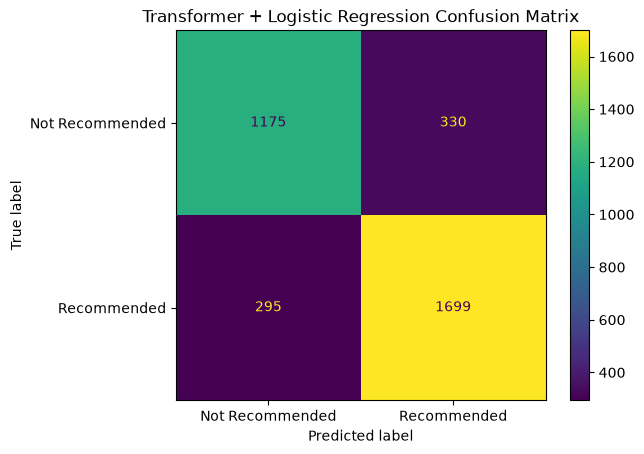

In [18]:
cm = confusion_matrix(y_test, y_pred_transformer)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Recommended', 'Recommended']
)

disp.plot()

plt.title('Transformer + Logistic Regression Confusion Matrix')
plt.show()

In [19]:
test_df = pd.read_csv('test.csv') 

test_df['user_review'] = test_df['user_review'].str.replace("Early Access Review", "", regex=False)
test_df['user_review'] = test_df['user_review'].str.replace("Product received for free", "", regex=False)

In [20]:
X_external = test_df['user_review'] 

X_external_embeddings = model.encode(
    X_external.tolist(),
    batch_size=16,
    show_progress_bar=True
)


Batches: 100%|██████████| 503/503 [00:49<00:00, 10.12it/s]


In [21]:
transformer_test_pred = lr_model.predict(
    X_external_embeddings
)

In [22]:
test_df['transformer_prediction'] = transformer_test_pred

test_df['transformer_label'] = test_df[
    'transformer_prediction'
].map({
    0: 'Not Recommended',
    1: 'Recommended'
})

In [23]:
transformer_probabilities = lr_model.predict_proba(
    X_external_embeddings
)

test_df['transformer_probability_recommended'] = (
    transformer_probabilities[:, 1]
)

In [24]:
test_df[
    [
        'title',
        'user_review',
        'transformer_label',
        'transformer_probability_recommended'
    ]
]

,title,user_review,transformer_label,transformer_probability_recommended
0,Counter-Strike: Global Offensive,"Nice graphics, new maps, weapons and models. B...",Recommended,0.659891
1,Counter-Strike: Global Offensive,I would not recommend getting into this at its...,Not Recommended,0.126208
2,Counter-Strike: Global Offensive,Edit 11/12/18I have tried playing CS:GO recent...,Not Recommended,0.242499
3,Counter-Strike: Global Offensive,The game is great. But the community is the wo...,Not Recommended,0.196055
4,Counter-Strike: Global Offensive,I thank TrulyRazor for buying this for me a lo...,Not Recommended,0.461826
...,...,...,...,...
8040,GUNS UP!,"Guns UP!Positive: Good Idea, addicting and lot...",Recommended,0.883914
8041,GUNS UP!,"After 170 hrs, my review. DO NOT SPEND ANY MON...",Recommended,0.531879
8042,GUNS UP!,Pros:-Fun GameplayCons: -Micro %$#*ing transac...,Recommended,0.910726
8043,GUNS UP!,"Actualy saucy, I definetly suggest to players ...",Recommended,0.902587


In [25]:
nb_predictions = pd.read_csv('nb_test_predictions.csv')

In [26]:
comparison_df = test_df.merge(
    nb_predictions,
    on='review_id'
)

In [27]:
comparison_df['models_agree'] = (
    comparison_df['nb_prediction']
    == comparison_df['transformer_prediction']
)

In [28]:
comparison_df['models_agree'].value_counts()

models_agree
True     6412
False    1633
Name: count, dtype: int64

In [29]:
comparison_df['models_agree'].value_counts(normalize=True) * 100

models_agree
True     79.701678
False    20.298322
Name: proportion, dtype: float64

In [30]:
disagreements = comparison_df[
    comparison_df['models_agree'] == False
]

disagreements[
    [
        'title',
        'user_review',
        'nb_label',
        'transformer_label'
    ]
].head(20)

,title,user_review,nb_label,transformer_label
0,Counter-Strike: Global Offensive,"Nice graphics, new maps, weapons and models. B...",Not Recommended,Recommended
4,Counter-Strike: Global Offensive,I thank TrulyRazor for buying this for me a lo...,Recommended,Not Recommended
11,Counter-Strike: Global Offensive,'CS:GO' <= Энэ ч үнэхээр хачин тоглоом шүү ......,Recommended,Not Recommended
12,Counter-Strike: Global Offensive,Being my favourite game I can only reccomend g...,Not Recommended,Recommended
13,Counter-Strike: Global Offensive,People wanted:1. 128 tick servers (waiting 6 y...,Recommended,Not Recommended
16,Counter-Strike: Global Offensive,"Extremely toxic community, you will be lucky t...",Recommended,Not Recommended
18,Counter-Strike: Global Offensive,I know this is like my first review.. Cool gam...,Not Recommended,Recommended
20,Counter-Strike: Global Offensive,This game will give you low trust factor after...,Not Recommended,Recommended
21,Counter-Strike: Global Offensive,I know this is like my first review.. Cool gam...,Not Recommended,Recommended
22,Counter-Strike: Global Offensive,Pros+ It's counterstrikeCons-A good portion of...,Not Recommended,Recommended
